In [1]:
import math
import random
import os

import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 500)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 16,          # 默认文字
    "axes.titlesize": 16,     # 标题
    "axes.labelsize": 16,     # 坐标轴标签
    "xtick.labelsize": 16,    # x 轴刻度
    "ytick.labelsize": 16,    # y 轴刻度
    "legend.fontsize": 16,    # 图例
})

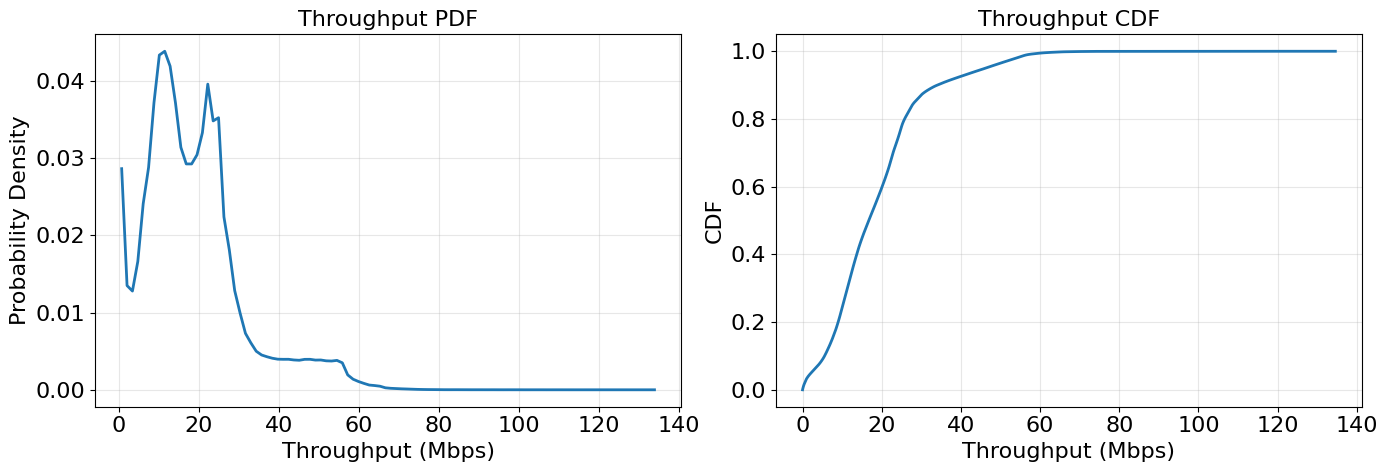

样本数量: 1715.0447222222222
平均吞吐量: 18.747432178065818
中位数: 16.7336022
最小值: 0.006990700000000001
最大值: 134.5939501
标准差: 12.3438799756111


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 读取网络数据
# =========================
network_dataset = pd.read_csv(
    'data/network_traces/NewFile-HighDensity-4G.txt',
    header=None
)

# 转换为一维数组，并去除缺失值
network_data = network_dataset.values.flatten()
network_data = network_data[~pd.isna(network_data)]
network_data = network_data[network_data != 0]
network_data = network_data.astype(float) / 1000. * 8

# =========================
# 2. PDF
# =========================
# 使用直方图统计概率密度
pdf, bins = np.histogram(
    network_data,
    bins=100,
    density=True
)

bin_centers = (bins[:-1] + bins[1:]) / 2

# =========================
# 3. CDF
# =========================
sorted_data = np.sort(network_data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

# =========================
# 4. 绘图
# =========================
plt.figure(figsize=(14, 5))

# PDF
plt.subplot(1, 2, 1)
plt.plot(bin_centers, pdf, linewidth=2)
plt.xlabel('Throughput (Mbps)')
plt.ylabel('Probability Density')
plt.title('Throughput PDF')
plt.grid(alpha=0.3)

# CDF
plt.subplot(1, 2, 2)
plt.plot(sorted_data, cdf, linewidth=2)
plt.xlabel('Throughput (Mbps)')
plt.ylabel('CDF')
plt.title('Throughput CDF')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# 5. 输出基本统计量
# =========================
print('样本数量:', len(network_data) / 3600)
print('平均吞吐量:', np.mean(network_data))
print('中位数:', np.median(network_data))
print('最小值:', np.min(network_data))
print('最大值:', np.max(network_data))
print('标准差:', np.std(network_data))